<a href="https://colab.research.google.com/github/supriyassutar3/Generative-Ai-Assignments/blob/main/assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of X: (300, 2)
First 5 points:
 [[-7.43086027 -7.89992284]
 [-7.91212323 -7.34157625]
 [-1.52214373  7.54927375]
 [ 4.37866139  3.29170191]
 [-9.32537663 -8.08981317]]


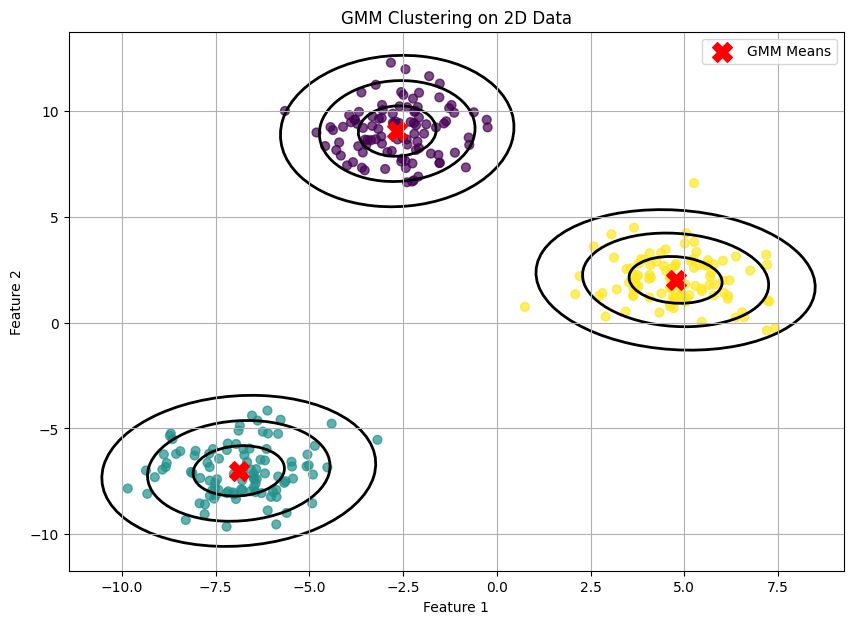


Estimated Means of GMM Components:

[[-2.65803969  9.04942651]
 [-6.88472071 -7.00475906]
 [ 4.76854828  2.01807919]]

Estimated Covariance Matrices of GMM Components:


Covariance Matrix for Component 1:
[[1.0781136  0.06290495]
 [0.06290495 1.42149784]]

Covariance Matrix for Component 2:
[[1.48264979 0.13786622]
 [0.13786622 1.41519133]]

Covariance Matrix for Component 3:
[[ 1.54128272 -0.14175789]
 [-0.14175789  1.22404828]]


In [1]:
# ============================================
# GMM Clustering on 2D Data - GenAI Lab
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

# -----------------------------
# 1. Generate 2D data
# -----------------------------
# 300 points, 3 clusters, 2 features
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

print("Shape of X:", X.shape)
print("First 5 points:\n", X[:5])

# -----------------------------
# 2. Fit GMM
# -----------------------------
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

# Get means and covariances
means = gmm.means_
covariances = gmm.covariances_

# -----------------------------
# 3. Function to draw ellipse
# -----------------------------
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()

    # Convert covariance matrix to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    # Draw 1-sigma, 2-sigma, 3-sigma ellipses
    for nsig in range(1, 4):
        ell = Ellipse(
            xy=position,
            width=nsig * width,
            height=nsig * height,
            angle=angle,
            fill=False,
            **kwargs
        )
        ax.add_patch(ell)

# -----------------------------
# 4. Plot results
# -----------------------------
plt.figure(figsize=(10, 7))

# Scatter plot of points colored by predicted label
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.7)

# Plot Gaussian means
plt.scatter(
    means[:, 0], means[:, 1],
    c='red', s=200, marker='X', label='GMM Means'
)

# Draw ellipses for each Gaussian component
for mean, covar in zip(means, covariances):
    draw_ellipse(mean, covar, edgecolor='black', linewidth=2)

plt.title("GMM Clustering on 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5. Output means and covariance matrices
# -----------------------------
print("\nEstimated Means of GMM Components:\n")
print(means)

print("\nEstimated Covariance Matrices of GMM Components:\n")
for i, cov in enumerate(covariances):
    print(f"\nCovariance Matrix for Component {i+1}:")
    print(cov)